### Extracción de características
En primer lugar, vamos a realizar la extracción de características con la metodología ISPC, que nos dará la potencia de las bandas de interés para los electrodos seleccionados.

In [1]:

from components_extraction import extract_features_from_epochs
import mne
from pathlib import Path

dir = Path("feature_data")
dir.mkdir(exist_ok=True)

def get_features(subject, session):

    path_input = f'C:\\Users\\aadel\\Desktop\\GCID\\Cuarto\\Segundo Cuatrimestre\\TFG\\python\\preprocessing\\session_{session}\\{subject}_0{session}_epochs_ica_a-epo.fif'

    epochs = mne.read_epochs(path_input, preload=True)

    print(f'Comienza la extracción del usuario::: {subject} de la sesión::: {session}')
    df = extract_features_from_epochs(
    epochs,
    baseline_window=(-10, -9),
    signal_window=(-1, 0)
)
    df.to_csv(dir / f'features_MW_study_session_{session}_subject_{subject}.csv', index=False)
    print("ÉXITO, archivo guardado como: " + f'features_MW_study_session_{session}_subject_{subject}.csv')

In [2]:
import os
import re
sessions =  [1,2]
patron = r".*ica_a-epo\.fif$"
for session in sessions:
    files = os.listdir(f'preprocessing/session_{session}')
    for file in files:
        t = re.compile(patron)
        match = t.search(file)
        if match:
            session = file[5:6]
            subject = file[:3]
            get_features(subject,session)

Reading C:\Users\aadel\Desktop\GCID\Cuarto\Segundo Cuatrimestre\TFG\python\preprocessing\session_1\001_01_epochs_ica_a-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =  -10000.00 ...       0.00 ms
        0 CTF compensation matrices available
Adding metadata with 14 columns
17 matching events found
No baseline correction applied
0 projection items activated
Comienza la extracción del usuario::: 001 de la sesión::: 1

FEATURE EXTRACTION
Epochs: 17
Channels: ['PO7', 'Pz', 'PO8', 'Fz']
Alpha band: 8.5-12 Hz
Theta band: 4-8 Hz
Baseline window: -10 to -9 s
Signal window: -1 to 0 s
⚠️  Warning: Channel Fz/C21 not found

✓ Using channels: {'PO7': 'A10', 'Pz': 'A19', 'PO8': 'B7'}
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).

Baseline samples: 257
Signal samples: 257

--- Creating Filters ---
⚠️  Warning: Filter SSE = 39.1677 (should be < 1.0)
   Consider increasing filter length or adjusting parameters
⚠️  Warning: Filter SSE = 28.653

### Entrenamiento con SVM

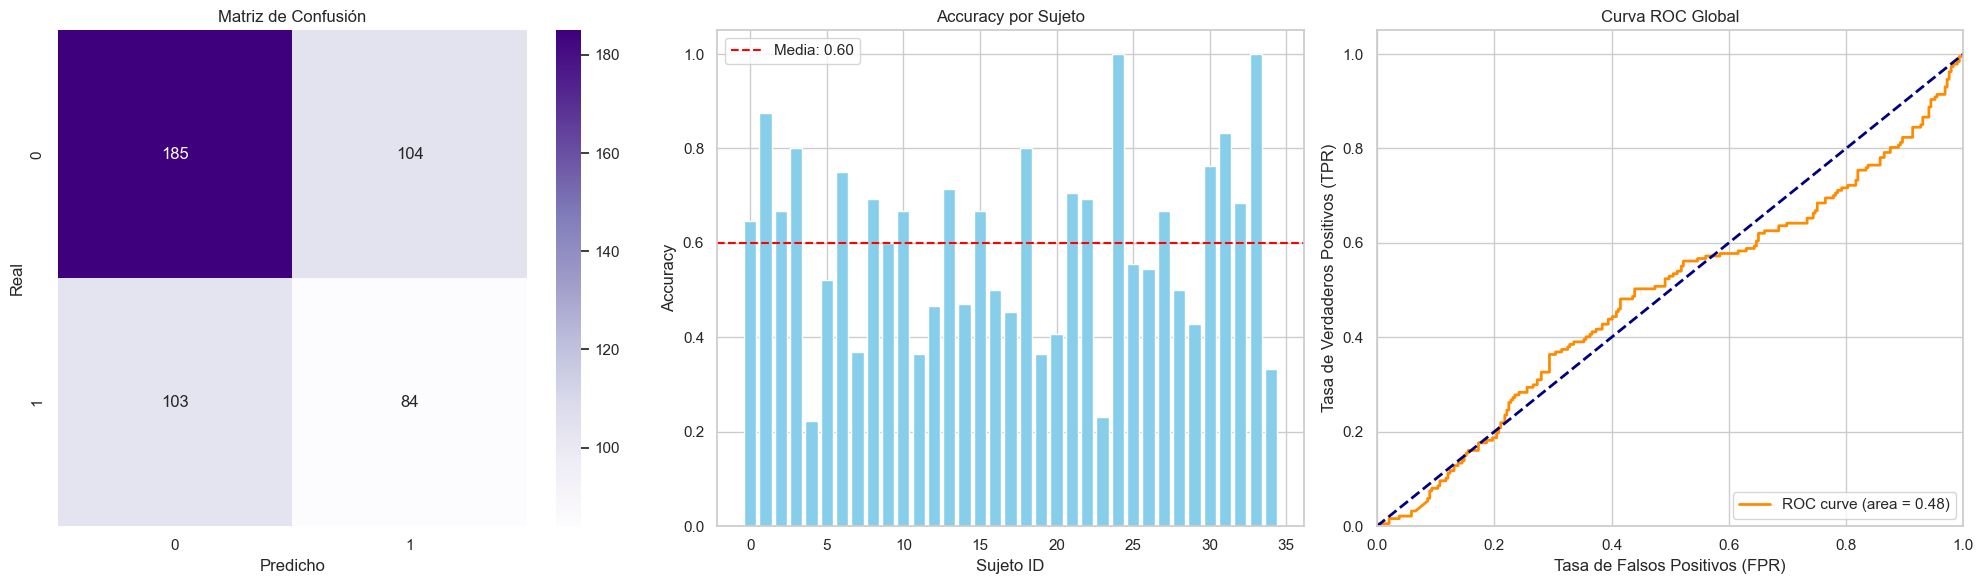


AUC Final: 0.4850
              precision    recall  f1-score   support

           0       0.64      0.64      0.64       289
           1       0.45      0.45      0.45       187

    accuracy                           0.57       476
   macro avg       0.54      0.54      0.54       476
weighted avg       0.57      0.57      0.57       476



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc)
files = os.listdir("feature_data")

data_list = []
for i, filename in enumerate(files):
    df = pd.read_csv("feature_data/" + filename)
    df['subject_id'] = i
    data_list.append(df)

full_dataset = pd.concat(data_list, ignore_index=True)

# 2. Preparación de variables
X = full_dataset.drop(['label', 'epoch_idx', 'subject_id', 'alpha_power_PO7_baseline', 'alpha_power_PO7_signal', 'theta_power_PO7_baseline', 'theta_power_PO7_signal', 'alpha_power_Pz_baseline','alpha_power_Pz_signal','theta_power_Pz_baseline','theta_power_Pz_signal','alpha_power_PO8_baseline','alpha_power_PO8_signal','theta_power_PO8_baseline','theta_power_PO8_signal'], axis=1)

y = full_dataset['label']
groups = full_dataset['subject_id']

# 3. Inicialización de LOGO
logo = LeaveOneGroupOut()
scaler = StandardScaler()

y_true_all = []
y_pred_all = []
y_probs_all = []  # Para ROC
subject_accuracies = []


# 4. Bucle de Validación Cruzada por Grupo (Sujeto)
for train_index, test_index in logo.split(X, y, groups=groups):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Escalado (Previene Data Leakage entre sujetos)
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Modelo SVM (probability=True para poder graficar curva ROC después)
    model = SVC(kernel='rbf', C=1.0, probability=True, class_weight='balanced')
    model.fit(X_train_scaled, y_train)

    # Predicción
    preds = model.predict(X_test_scaled)

    # Guardar resultados globales y por sujeto
    y_true_all.extend(y_test)
    y_pred_all.extend(preds)
    y_probs_all.extend(model.predict_proba(X_test_scaled)[:, 1])
    subject_accuracies.append(accuracy_score(y_test, preds))

# --- 5. VISUALIZACIÓN DE RESULTADOS ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.set_theme(style="whitegrid")

# A. Matriz de Confusión
cm = confusion_matrix(y_true_all, y_pred_all)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0])
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

# B. Precisión por Sujeto
axes[1].bar(range(len(subject_accuracies)), subject_accuracies, color='skyblue')
axes[1].axhline(np.mean(subject_accuracies), color='red', linestyle='--', label=f'Media: {np.mean(subject_accuracies):.2f}')
axes[1].set_title('Accuracy por Sujeto')
axes[1].set_xlabel('Sujeto ID')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# C. Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_true_all, y_probs_all)
roc_auc = auc(fpr, tpr)

axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[2].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[2].set_title('Curva ROC Global')
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Resumen numérico
print(f"\nAUC Final: {roc_auc:.4f}")
print(classification_report(y_true_all, y_pred_all))

In [14]:
import pandas as pd
files = os.listdir("feature_data")

data_list = []
for i, filename in enumerate(files):
    df = pd.read_csv("feature_data/" + filename)
    df['subject_id'] = i
    data_list.append(df)

full_dataset = pd.concat(data_list, ignore_index=True)
data_list = []
for filename in files:
    print(filename)
    df = pd.read_csv("feature_data/" + filename)
    data_list.append(df)

full_dataset = pd.concat(data_list, ignore_index=True)
full_dataset.info()

features_MW_study_session_1_subject_001.csv
features_MW_study_session_1_subject_002.csv
features_MW_study_session_1_subject_003.csv
features_MW_study_session_1_subject_004.csv
features_MW_study_session_1_subject_005.csv
features_MW_study_session_1_subject_006.csv
features_MW_study_session_1_subject_007.csv
features_MW_study_session_1_subject_008.csv
features_MW_study_session_1_subject_010.csv
features_MW_study_session_1_subject_011.csv
features_MW_study_session_1_subject_012.csv
features_MW_study_session_1_subject_013.csv
features_MW_study_session_1_subject_015.csv
features_MW_study_session_1_subject_016.csv
features_MW_study_session_1_subject_018.csv
features_MW_study_session_1_subject_019.csv
features_MW_study_session_1_subject_020.csv
features_MW_study_session_1_subject_021.csv
features_MW_study_session_1_subject_022.csv
features_MW_study_session_1_subject_023.csv
features_MW_study_session_1_subject_024.csv
features_MW_study_session_2_subject_001.csv
features_MW_study_session_2_subj

### Prueba para ver la diferencia en las clases que causan los distintos campos
#### Conclusión: las bandas theta y alfa no tienen el impacto que nos gustaría, vamos a probar con solo ISPC.

Calculando promedios por sujeto...


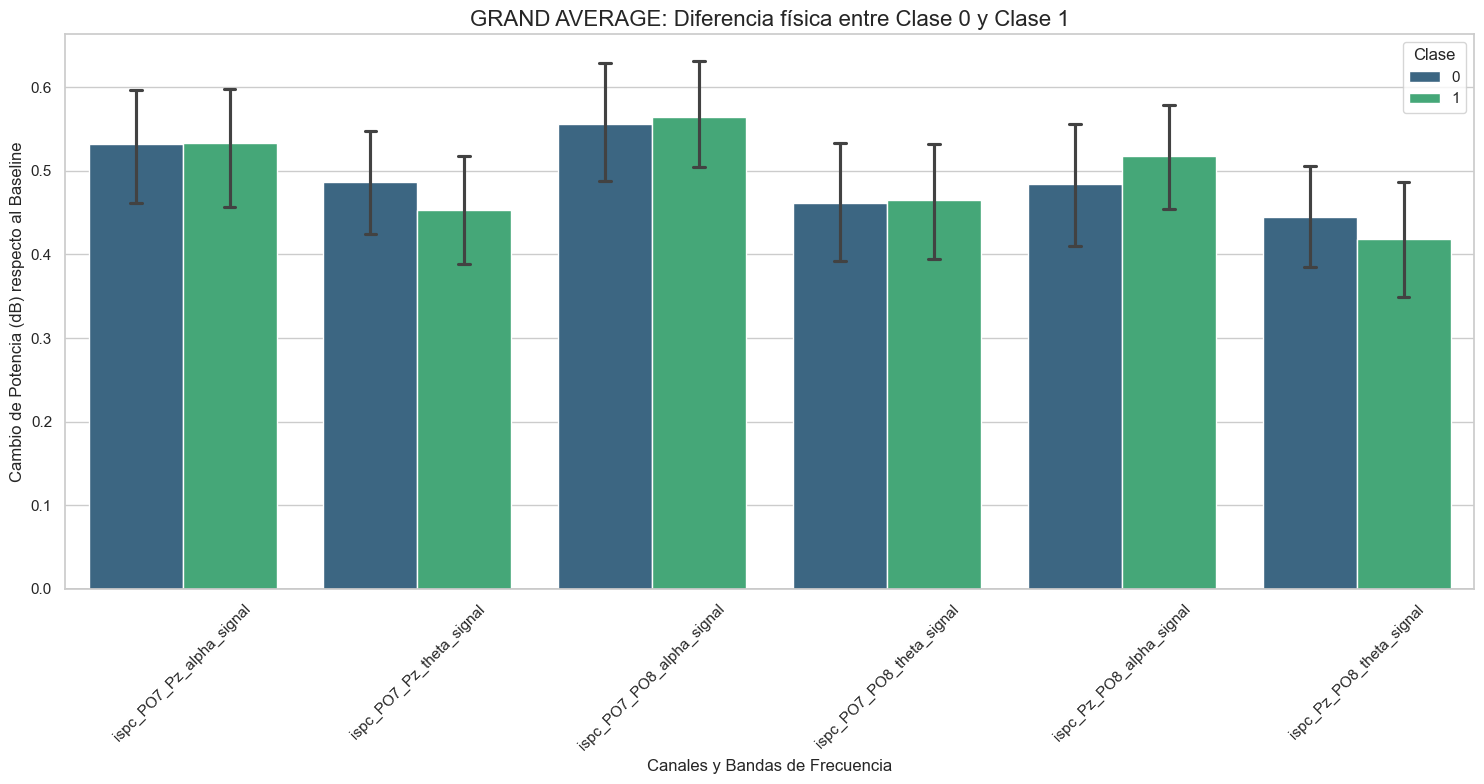


--- Diferencias Medias Globales ---
       ispc_PO7_Pz_alpha_signal  ispc_PO7_Pz_theta_signal  \
label                                                       
0                      0.532428                  0.486099   
1                      0.532672                  0.453509   

       ispc_PO7_PO8_alpha_signal  ispc_PO7_PO8_theta_signal  \
label                                                         
0                       0.556373                   0.461085   
1                       0.564687                   0.464551   

       ispc_Pz_PO8_alpha_signal  ispc_Pz_PO8_theta_signal  
label                                                      
0                      0.484245                  0.445273  
1                      0.517464                  0.418511  


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

path_data = "feature_data/"
files = [f for f in os.listdir(path_data) if f.endswith('.csv')]

# Variables que queremos analizar
feature_base = [c for c in df.columns if 'ispc' in c and 'signal' in c]

all_subject_means = []

print("Calculando promedios por sujeto...")

for filename in files:
    df = pd.read_csv(path_data + filename)


    subject_mean = df.groupby('label')[[f'{f}' for f in feature_base]].mean().reset_index()
    subject_mean['subject_id'] = filename
    all_subject_means.append(subject_mean)

# 3. Consolidamos el Gran Dataset de Promedios
grand_df = pd.concat(all_subject_means, ignore_index=True)

# 4. VISUALIZACIÓN
plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

# Convertimos a formato "largo" para seaborn
plot_df = grand_df.melt(id_vars=['label', 'subject_id'],
                        value_vars=[f'{f}' for f in feature_base],
                        var_name='Feature', value_name='dB_Change')

# Graficamos con intervalos de confianza (ci=95)
ax = sns.barplot(data=plot_df, x='Feature', y='dB_Change', hue='label',
                 palette='viridis', capsize=.1, errorbar=('ci', 95))

plt.title("GRAND AVERAGE: Diferencia física entre Clase 0 y Clase 1", fontsize=16)
plt.ylabel("Cambio de Potencia (dB) respecto al Baseline")
plt.xlabel("Canales y Bandas de Frecuencia")
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=1) # Línea de "No hay cambio"
plt.legend(title='Clase')
plt.tight_layout()
plt.show()

# Resumen numérico
print("\n--- Diferencias Medias Globales ---")
summary = grand_df.groupby('label')[[f'{f}' for f in feature_base]].mean()
print(summary)

Procesando variables Élite...
Entrenando con 6 variables seleccionadas...

--- AUC HÍBRIDO FINAL: 0.5144 ---
              precision    recall  f1-score   support

           0       0.60      0.65      0.63       289
           1       0.38      0.33      0.36       187

    accuracy                           0.53       476
   macro avg       0.49      0.49      0.49       476
weighted avg       0.52      0.53      0.52       476



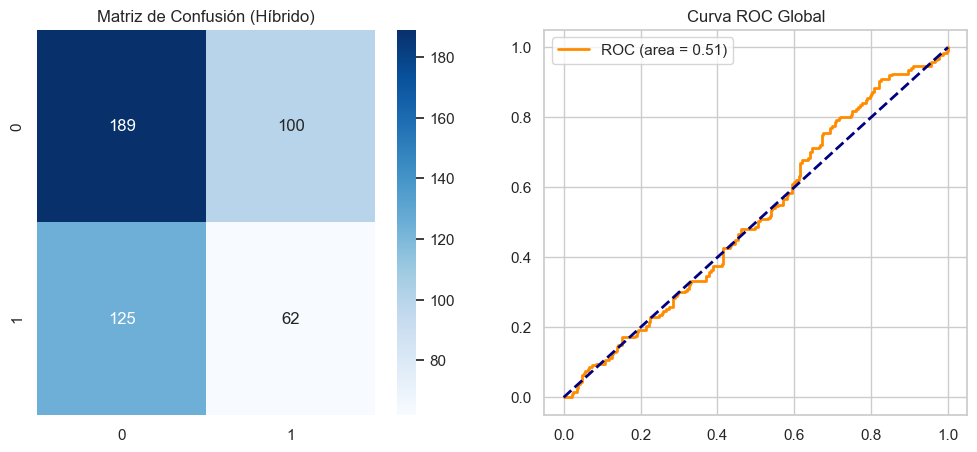

In [9]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc)

# 1. PREPARACIÓN DE DATOS
path_data = "feature_data/"
files = [f for f in os.listdir(path_data) if f.endswith('.csv')]
processed_data = []

# Definimos las variables "Elite" basadas en tus heatmaps y medias
# Incluimos las que mostraron correlación > 0.03 o diferencias claras
power_features = ['alpha_power_Pz', 'alpha_power_PO7', 'theta_power_PO8']
ispc_features = ['ispc_PO7_PO8_alpha_signal', 'ispc_Pz_PO8_alpha_signal', 'ispc_PO7_Pz_theta_signal']

print("Procesando variables Élite...")
for filename in files:
    df = pd.read_csv(path_data + filename)

    # Transformación dB para potencia
    for feat in power_features:
        df[f'{feat}_dB'] = 10 * np.log10(df[f'{feat}_signal'] / (df[f'{feat}_baseline'] + 1e-6))

    # Selección de columnas finales
    selected_cols = [f'{f}_dB' for f in power_features] + ispc_features
    X_sub = df[selected_cols].copy()

    # RobustScaler por sujeto (mejor para manejar esos picos de -48dB)
    scaler = RobustScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_sub), columns=selected_cols)

    X_scaled['label'] = df['label']
    X_scaled['subject_id'] = filename
    processed_data.append(X_scaled)

full_dataset = pd.concat(processed_data, ignore_index=True).fillna(0)

# 2. CONFIGURACIÓN DEL MODELO
X = full_dataset.drop(['label', 'subject_id'], axis=1)
y = full_dataset['label']
groups = full_dataset['subject_id']

logo = LeaveOneGroupOut()
# Usamos Random Forest para capturar interacciones no lineales entre Power e ISPC
rf = RandomForestClassifier(n_estimators=150, max_depth=4, class_weight='balanced', random_state=42)

y_true_all, y_pred_all, y_probs_all = [], [], []

print(f"Entrenando con {X.shape[1]} variables seleccionadas...")

for train_index, test_index in logo.split(X, y, groups=groups):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    rf.fit(X_train, y_train)

    y_pred_all.extend(rf.predict(X_test))
    y_probs_all.extend(rf.predict_proba(X_test)[:, 1])
    y_true_all.extend(y_test)

# 3. RESULTADOS
fpr, tpr, _ = roc_curve(y_true_all, y_probs_all)
roc_auc = auc(fpr, tpr)

print(f"\n--- AUC HÍBRIDO FINAL: {roc_auc:.4f} ---")
print(classification_report(y_true_all, y_pred_all))

# Matriz de Confusión
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_true_all, y_pred_all), annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión (Híbrido)")

# Curva ROC
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title("Curva ROC Global")
plt.legend()
plt.show()

### Entrenamiento intrasujeto

Iniciando entrenamiento individual para 35 sujetos...
Sujeto features_MW_study_session_1_subject_001.csv: Accuracy = 0.9200
Sujeto features_MW_study_session_1_subject_002.csv: Accuracy = 0.9267
Sujeto features_MW_study_session_1_subject_003.csv saltado: Solo tiene 3 épocas.
Sujeto features_MW_study_session_1_subject_004.csv saltado: Solo tiene 5 épocas.
Sujeto features_MW_study_session_1_subject_005.csv saltado: Solo tiene 9 épocas.
Sujeto features_MW_study_session_1_subject_006.csv: Accuracy = 0.7905
Sujeto features_MW_study_session_1_subject_007.csv saltado: Solo tiene 8 épocas.
Sujeto features_MW_study_session_1_subject_008.csv: Accuracy = 0.7733
Sujeto features_MW_study_session_1_subject_010.csv saltado: Solo tiene 13 épocas.
Sujeto features_MW_study_session_1_subject_011.csv: Accuracy = 0.7500


C:\Users\aadel\Desktop\GCID\Cuarto\Segundo Cuatrimestre\TFG\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\aadel\Desktop\GCID\Cuarto\Segundo Cuatrimestre\TFG\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Sujeto features_MW_study_session_1_subject_012.csv: Accuracy = 0.8500
Sujeto features_MW_study_session_1_subject_013.csv saltado: Solo tiene 11 épocas.
Sujeto features_MW_study_session_1_subject_015.csv: Accuracy = 0.6667
Sujeto features_MW_study_session_1_subject_016.csv saltado: Solo tiene 7 épocas.
Sujeto features_MW_study_session_1_subject_018.csv: Accuracy = 0.8800
Sujeto features_MW_study_session_1_subject_019.csv: Accuracy = 0.6667
Sujeto features_MW_study_session_1_subject_020.csv: Accuracy = 0.5667
Sujeto features_MW_study_session_1_subject_021.csv: Accuracy = 0.7700
Sujeto features_MW_study_session_1_subject_022.csv saltado: Solo tiene 5 épocas.
Sujeto features_MW_study_session_1_subject_023.csv saltado: Solo tiene 11 épocas.
Sujeto features_MW_study_session_1_subject_024.csv: Accuracy = 0.4095
Sujeto features_MW_study_session_2_subject_001.csv: Accuracy = 0.7800
Sujeto features_MW_study_session_2_subject_002.csv saltado: Solo tiene 13 épocas.
Sujeto features_MW_study_session

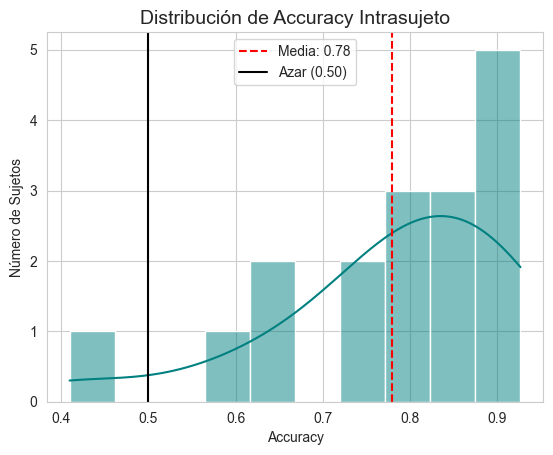

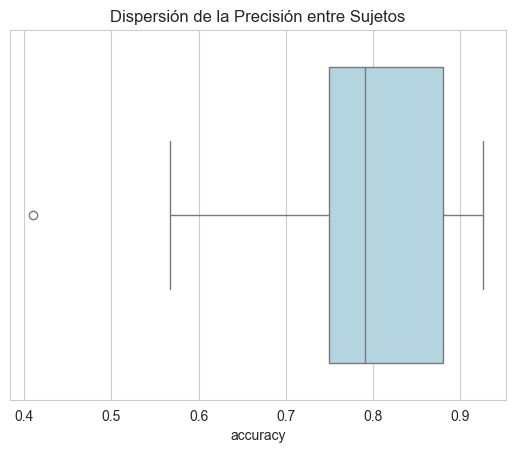

In [3]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.utils import resample

path_data = "feature_data/"
files = [f for f in os.listdir(path_data) if f.endswith('.csv')]

# Variables Elite (según nuestro análisis previo y el paper)
power_features = ['alpha_power_Pz', 'alpha_power_PO7', 'theta_power_PO8']
ispc_features = ['ispc_PO7_PO8_alpha_signal', 'ispc_Pz_PO8_alpha_signal', 'ispc_PO7_Pz_theta_signal']

results = []

print(f"Iniciando entrenamiento individual para {len(files)} sujetos...")

for filename in files:
    # 1. Carga de datos del sujeto
    df = pd.read_csv(path_data + filename)

    # 2. Ingeniería de variables (dB)
    for feat in power_features:
        df[f'{feat}_dB'] = 10 * np.log10(df[f'{feat}_signal'] / (df[f'{feat}_baseline'] + 1e-6))

    selected_cols = [f'{f}_dB' for f in power_features] + ispc_features
    X = df[selected_cols].fillna(0)
    y = df['label']

    # 3. Oversampling de la clase minoritaria (como en el paper)
    df_temp = pd.concat([X, y], axis=1)
    df_majority = df_temp[df_temp.label == 0]
    df_minority = df_temp[df_temp.label == 1]

# Dentro del bucle, después de cargar el df:
    if len(df) < 15: # Puedes ajustar este umbral (el paper usó 30 por clase)
        print(f"Sujeto {filename} saltado: Solo tiene {len(df)} épocas.")
        continue
    # Si la clase 1 es la minoritaria, la aumentamos
    if len(df_minority) < len(df_majority) and len(df_minority) > 0:
        df_minority_upsampled = resample(df_minority,
                                         replace=True,     # sample with replacement
                                         n_samples=len(df_majority),    # to match majority class
                                         random_state=42)
        df_balanced = pd.concat([df_majority, df_minority_upsampled])
    else:
        df_balanced = df_temp

    X_bal = df_balanced.drop('label', axis=1)
    y_bal = df_balanced['label']

    # 4. Validación Cruzada Interna (Stratified K-Fold)
    # Usamos 5-folds debido a que hay pocos datos por sujeto
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    subj_accuracies = []

    for train_idx, test_idx in skf.split(X_bal, y_bal):
        X_train, X_test = X_bal.iloc[train_idx], X_bal.iloc[test_idx]
        y_train, y_test = y_bal.iloc[train_idx], y_bal.iloc[test_idx]

        # Escalado Robusto
        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Modelo (Random Forest con poca profundidad para evitar overfitting)
        model = SVC(kernel = "rbf", class_weight="balanced", C=1)
        model.fit(X_train_scaled, y_train)

        preds = model.predict(X_test_scaled)
        subj_accuracies.append(accuracy_score(y_test, preds))

    mean_acc = np.mean(subj_accuracies)
    results.append({'subject': filename, 'accuracy': mean_acc})
    print(f"Sujeto {filename}: Accuracy = {mean_acc:.4f}")

# 5. RESULTADOS GLOBALES
final_df = pd.DataFrame(results)
print("\n--- RESUMEN FINAL ---")
print(f"Precisión Media de la población: {final_df['accuracy'].mean():.4f}")
print(f"Mejor Sujeto: {final_df['accuracy'].max():.4f}")
print(f"Peor Sujeto: {final_df['accuracy'].min():.4f}")

import matplotlib.pyplot as plt
import seaborn as sns

# Convertimos los resultados a DataFrame si no lo habías hecho
results_df = pd.DataFrame(results)

# --- 1. HISTOGRAMA DE PRECISIÓN ---
sns.histplot(results_df['accuracy'], bins=10, kde=True, color='teal')
plt.axvline(results_df['accuracy'].mean(), color='red', linestyle='--', label=f"Media: {results_df['accuracy'].mean():.2f}")
plt.axvline(0.5, color='black', linestyle='-', label="Azar (0.50)")
plt.title("Distribución de Accuracy Intrasujeto", fontsize=14)
plt.xlabel("Accuracy")
plt.ylabel("Número de Sujetos")
plt.legend()
plt.show()

# --- 2. BOXPLOT PARA DETECTAR OUTLIERS ---
sns.boxplot(x=results_df['accuracy'], color='lightblue')
plt.title("Dispersión de la Precisión entre Sujetos")
plt.show()

# --- 3. EXTRACCIÓN DE IMPORTANCIA DE VARIABLES ---
# (Ejecuta esto dentro del bucle de entrenamiento anterior para guardar las importancias)
# feature_importances = model.feature_importances_
# results.append({'subject': filename, 'accuracy': mean_acc, 'importances': feature_importances})

# Si guardaste las importancias, puedes promediarlas:
# all_imps = np.mean([r['importances'] for r in results], axis=0)
# sns.barplot(x=selected_cols, y=all_imps)
# plt.xticks(rotation=45)
# plt.title("¿Qué variables mandan a nivel global?")

### Permutation test

In [2]:
import pandas as pd
import numpy as np
import os
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.utils import resample, shuffle

path_data = "feature_data/"
files = [f for f in os.listdir(path_data) if f.endswith('.csv')]

# Variables seleccionadas
power_features = ['alpha_power_Pz', 'alpha_power_PO7', 'theta_power_PO8']
ispc_features = ['ispc_PO7_PO8_alpha_signal', 'ispc_Pz_PO8_alpha_signal', 'ispc_PO7_Pz_theta_signal']

n_permutations = 100 # Número de veces que barajamos las etiquetas
final_results = []

print(f"Iniciando Permutation Test...")

for filename in files:
    df = pd.read_csv(path_data + filename)
    if len(df) < 15: continue

    # Preparación de features
    for feat in power_features:
        df[f'{feat}_dB'] = 10 * np.log10(df[f'{feat}_signal'] / (df[f'{feat}_baseline'] + 1e-6))

    selected_cols = [f'{f}_dB' for f in power_features] + ispc_features
    X = df[selected_cols].fillna(0)
    y = df['label']

    # --- MODELO ORIGINAL (Sin barajar) ---
    # (Usamos la misma lógica de oversampling y cross-validation del paso anterior)
    def get_accuracy(X_in, y_in, permute=False):
        if permute:
            y_in = shuffle(y_in.values, random_state=None) # Barajamos etiquetas

        # Balanceo (Oversampling como en el paper)
        df_tmp = pd.concat([X_in, pd.Series(y_in, name='label', index=X_in.index)], axis=1)
        df_maj = df_tmp[df_tmp.label == 0]
        df_min = df_tmp[df_tmp.label == 1]
        if 0 < len(df_min) < len(df_maj):
            df_min_up = resample(df_min, replace=True, n_samples=len(df_maj))
            df_bal = pd.concat([df_maj, df_min_up])
        else: df_bal = df_tmp

        X_b, y_b = df_bal.drop('label', axis=1), df_bal['label']

        skf = StratifiedKFold(n_splits=min(5, len(y_b)), shuffle=True)
        accs = []
        for train_idx, test_idx in skf.split(X_b, y_b):
            model = SVC(kernel = "rbf", class_weight="balanced", C=1)
            scaler = RobustScaler()
            X_tr = scaler.fit_transform(X_b.iloc[train_idx])
            X_te = scaler.transform(X_b.iloc[test_idx])
            model.fit(X_tr, y_b.iloc[train_idx])
            accs.append(accuracy_score(y_b.iloc[test_idx], model.predict(X_te)))
        return np.mean(accs)

    original_acc = get_accuracy(X, y, permute=False)

    # --- PERMUTACIONES ---
    perm_accs = [get_accuracy(X, y, permute=True) for _ in range(n_permutations)]

    # Valor p: proporción de veces que el azar superó a tu resultado real
    p_value = np.sum(np.array(perm_accs) >= original_acc) / n_permutations

    final_results.append({
        'subject': filename,
        'original_acc': original_acc,
        'chance_acc': np.mean(perm_accs),
        'p_value': p_value
    })
    print(f"Sujeto {filename} | Real: {original_acc:.2f} | Azar: {np.mean(perm_accs):.2f} | p: {p_value:.3f}")

# Visualización de resultados
res_df = pd.DataFrame(final_results)
print(f"\nAccuracy Media Real: {res_df['original_acc'].mean():.4f}")
print(f"Accuracy Media Azar: {res_df['chance_acc'].mean():.4f}")

Iniciando Permutation Test...
Sujeto features_MW_study_session_1_subject_001.csv | Real: 0.70 | Azar: 0.80 | p: 0.820
Sujeto features_MW_study_session_1_subject_002.csv | Real: 0.96 | Azar: 0.85 | p: 0.100
Sujeto features_MW_study_session_1_subject_006.csv | Real: 0.76 | Azar: 0.80 | p: 0.700
Sujeto features_MW_study_session_1_subject_008.csv | Real: 0.77 | Azar: 0.75 | p: 0.490
Sujeto features_MW_study_session_1_subject_011.csv | Real: 0.72 | Azar: 0.70 | p: 0.500


C:\Users\aadel\Desktop\GCID\Cuarto\Segundo Cuatrimestre\TFG\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\aadel\Desktop\GCID\Cuarto\Segundo Cuatrimestre\TFG\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\aadel\Desktop\GCID\Cuarto\Segundo Cuatrimestre\TFG\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\aadel\Desktop\GCID\Cuarto\Segundo Cuatrimestre\TFG\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\aadel\Desktop\GCID\Cuarto\Segundo Cuatrimestre\TFG\

Sujeto features_MW_study_session_1_subject_012.csv | Real: 0.90 | Azar: 0.83 | p: 0.310
Sujeto features_MW_study_session_1_subject_015.csv | Real: 0.67 | Azar: 0.55 | p: 0.330
Sujeto features_MW_study_session_1_subject_018.csv | Real: 0.64 | Azar: 0.76 | p: 0.890
Sujeto features_MW_study_session_1_subject_019.csv | Real: 0.53 | Azar: 0.50 | p: 0.580
Sujeto features_MW_study_session_1_subject_020.csv | Real: 0.57 | Azar: 0.56 | p: 0.530


C:\Users\aadel\Desktop\GCID\Cuarto\Segundo Cuatrimestre\TFG\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\aadel\Desktop\GCID\Cuarto\Segundo Cuatrimestre\TFG\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\aadel\Desktop\GCID\Cuarto\Segundo Cuatrimestre\TFG\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\aadel\Desktop\GCID\Cuarto\Segundo Cuatrimestre\TFG\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\aadel\Desktop\GCID\Cuarto\Segundo Cuatrimestre\TFG\

Sujeto features_MW_study_session_1_subject_021.csv | Real: 0.83 | Azar: 0.84 | p: 0.500
Sujeto features_MW_study_session_1_subject_024.csv | Real: 0.51 | Azar: 0.51 | p: 0.460
Sujeto features_MW_study_session_2_subject_001.csv | Real: 0.70 | Azar: 0.75 | p: 0.750
Sujeto features_MW_study_session_2_subject_007.csv | Real: 0.92 | Azar: 0.90 | p: 0.480
Sujeto features_MW_study_session_2_subject_010.csv | Real: 0.89 | Azar: 0.74 | p: 0.050
Sujeto features_MW_study_session_2_subject_011.csv | Real: 0.85 | Azar: 0.91 | p: 0.890
Sujeto features_MW_study_session_2_subject_018.csv | Real: 0.85 | Azar: 0.72 | p: 0.130

Accuracy Media Real: 0.7505
Accuracy Media Azar: 0.7333


### Experimento 6



Iniciando entrenamiento individual para 35 sujetos...
Sujeto features_MW_study_session_1_subject_001.csv: Accuracy Real = 0.7000
Sujeto features_MW_study_session_1_subject_002.csv: Accuracy Real = 0.6889
Sujeto features_MW_study_session_1_subject_003.csv saltado: Solo tiene 3 épocas.
Sujeto features_MW_study_session_1_subject_004.csv saltado: Solo tiene 5 épocas.
Sujeto features_MW_study_session_1_subject_005.csv saltado: Solo tiene 9 épocas.
Sujeto features_MW_study_session_1_subject_006.csv: Accuracy Real = 0.4300
Sujeto features_MW_study_session_1_subject_007.csv saltado: Solo tiene 8 épocas.
Sujeto features_MW_study_session_1_subject_008.csv: Accuracy Real = 0.5667
Sujeto features_MW_study_session_1_subject_010.csv saltado: Solo tiene 13 épocas.
Sujeto features_MW_study_session_1_subject_011.csv: Accuracy Real = 0.3333
Sujeto features_MW_study_session_1_subject_012.csv: Accuracy Real = 0.8889
Sujeto features_MW_study_session_1_subject_013.csv saltado: Solo tiene 11 épocas.
Sujeto f

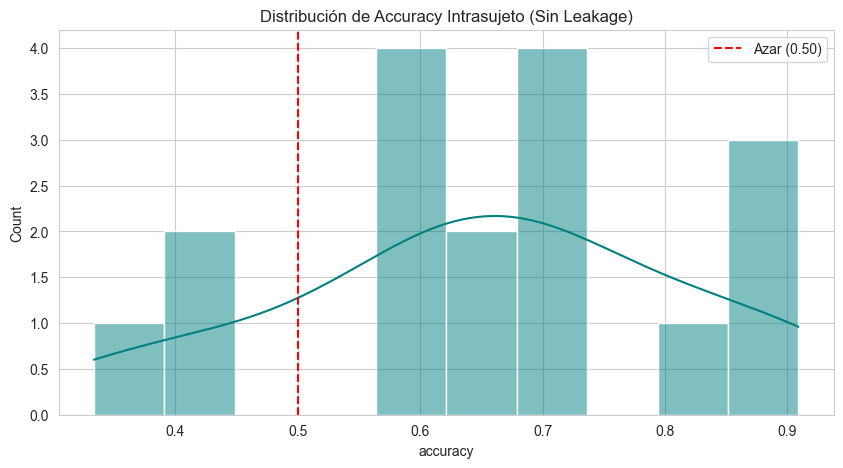

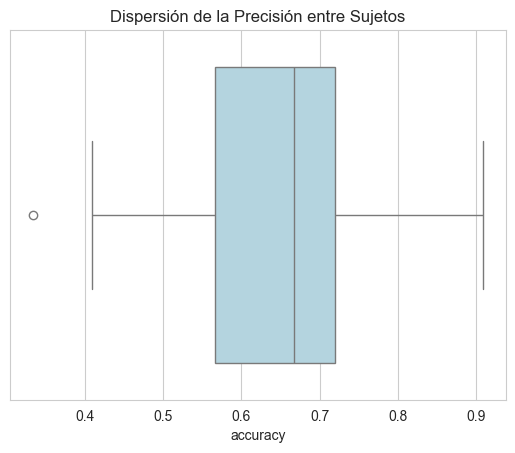

In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.utils import resample

path_data = "feature_data/"
files = [f for f in os.listdir(path_data) if f.endswith('.csv')]

power_features = ['alpha_power_Pz', 'alpha_power_PO7', 'theta_power_PO8']
ispc_features = ['ispc_PO7_PO8_alpha_signal', 'ispc_Pz_PO8_alpha_signal', 'ispc_PO7_Pz_theta_signal']

results = []

print(f"Iniciando entrenamiento individual para {len(files)} sujetos...")

for filename in files:
    df = pd.read_csv(path_data + filename)

    # Filtro de sujetos con pocos datos
    if len(df) < 15:
        print(f"Sujeto {filename} saltado: Solo tiene {len(df)} épocas.")
        continue

    # 1. Feature Engineering
    for feat in power_features:
        df[f'{feat}_dB'] = 10 * np.log10(df[f'{feat}_signal'] / (df[f'{feat}_baseline'] + 1e-6))

    selected_cols = [f'{f}_dB' for f in power_features] + ispc_features
    X = df[selected_cols].fillna(0)
    y = df['label']

    # 2. Configuración de Validación Cruzada
    # Usamos menos splits si el sujeto tiene poquísimos datos
    n_splits = min(5, y.value_counts().min())
    if n_splits < 2:
        print(f"Sujeto {filename} saltado: No hay suficientes muestras de ambas clases.")
        continue

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    subj_accuracies = []

    # 3. Bucle de Folds (Aquí es donde evitamos el Data Leakage)
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # --- BALANCEO: Solo sobre el set de entrenamiento ---
        train_df = pd.concat([X_train, y_train], axis=1)
        df_maj = train_df[train_df.label == 0]
        df_min = train_df[train_df.label == 1]

        if 0 < len(df_min) < len(df_maj):
            df_min_up = resample(df_min, replace=True, n_samples=len(df_maj), random_state=42)
            train_df_bal = pd.concat([df_maj, df_min_up])
            X_train_final = train_df_bal.drop('label', axis=1)
            y_train_final = train_df_bal['label']
        else:
            X_train_final, y_train_final = X_train, y_train

        # --- ESCALADO Y MODELADO ---
        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train_final)
        X_test_scaled = scaler.transform(X_test)

        # Modelo ajustado para evitar overfitting
        model = SVC(kernel = "rbf", C=1.0, class_weight="balanced")
        model.fit(X_train_scaled, y_train_final)

        preds = model.predict(X_test_scaled)
        subj_accuracies.append(accuracy_score(y_test, preds))

    # Guardar promedio del sujeto
    mean_acc = np.mean(subj_accuracies)
    results.append({'subject': filename, 'accuracy': mean_acc})
    print(f"Sujeto {filename}: Accuracy Real = {mean_acc:.4f}")

# 4. RESULTADOS FINALES Y VISUALIZACIÓN
results_df = pd.DataFrame(results)
print("\n--- RESUMEN FINAL CORREGIDO ---")
print(f"Precisión Media: {results_df['accuracy'].mean():.4f}")

# Histograma
plt.figure(figsize=(10, 5))
sns.histplot(results_df['accuracy'], bins=10, kde=True, color='teal')
plt.axvline(0.5, color='red', linestyle='--', label="Azar (0.50)")
plt.title("Distribución de Accuracy Intrasujeto (Sin Leakage)")
plt.legend()
plt.show()


# --- 2. BOXPLOT PARA DETECTAR OUTLIERS ---
sns.boxplot(x=results_df['accuracy'], color='lightblue')
plt.title("Dispersión de la Precisión entre Sujetos")
plt.show()

### Test de permutaciones

Iniciando Permutation Test (N=100) por sujeto...
Sujeto: features_MW_study_session_1_subject_001.csv | Real: 0.650 | Azar: 0.649 | p: 0.535
Sujeto: features_MW_study_session_1_subject_002.csv | Real: 0.867 | Azar: 0.699 | p: 0.040
Sujeto: features_MW_study_session_1_subject_006.csv | Real: 0.380 | Azar: 0.632 | p: 1.000
Sujeto: features_MW_study_session_1_subject_008.csv | Real: 0.633 | Azar: 0.599 | p: 0.446
Sujeto: features_MW_study_session_1_subject_011.csv | Real: 0.467 | Azar: 0.548 | p: 0.901
Sujeto: features_MW_study_session_1_subject_012.csv | Real: 0.889 | Azar: 0.832 | p: 0.396
Sujeto: features_MW_study_session_1_subject_015.csv | Real: 0.667 | Azar: 0.566 | p: 0.307
Sujeto: features_MW_study_session_1_subject_018.csv | Real: 0.700 | Azar: 0.558 | p: 0.158
Sujeto: features_MW_study_session_1_subject_019.csv | Real: 0.667 | Azar: 0.507 | p: 0.248
Sujeto: features_MW_study_session_1_subject_020.csv | Real: 0.533 | Azar: 0.544 | p: 0.574
Sujeto: features_MW_study_session_1_subje

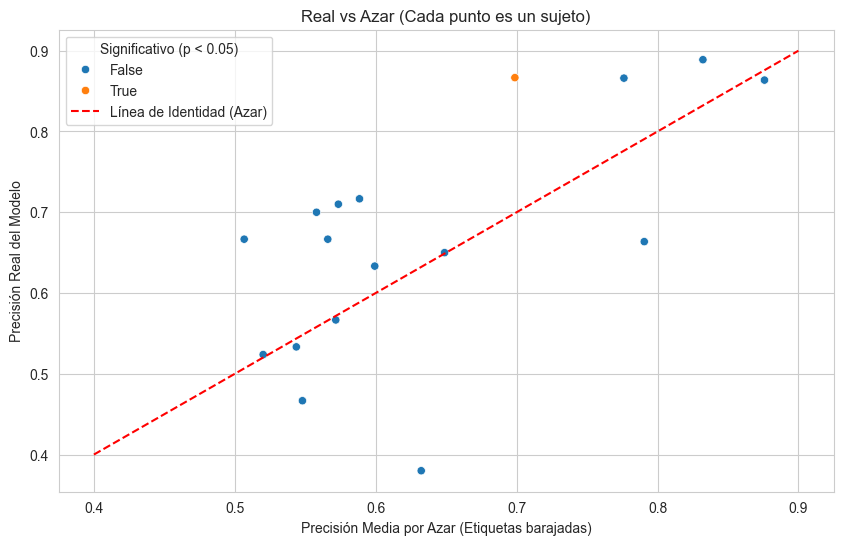


Sujetos significativos: 1 de 17


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.utils import resample, shuffle

path_data = "feature_data/"


files = [f for f in os.listdir(path_data) if f.endswith('.csv')]

power_features = ['alpha_power_Pz', 'alpha_power_PO7', 'theta_power_PO8']
ispc_features = ['ispc_PO7_PO8_alpha_signal', 'ispc_Pz_PO8_alpha_signal', 'ispc_PO7_Pz_theta_signal']

n_permutations = 100
permutation_results = []

print(f"Iniciando Permutation Test (N={n_permutations}) por sujeto...")

for filename in files:
    df = pd.read_csv(path_data + filename)
    if len(df) < 15: continue

    # Feature Engineering
    for feat in power_features:
        df[f'{feat}_dB'] = 10 * np.log10(df[f'{feat}_signal'] / (df[f'{feat}_baseline'] + 1e-6))

    selected_cols = [f'{f}_dB' for f in power_features] + ispc_features
    X = df[selected_cols].fillna(0)
    y = df['label']

    def evaluate_model(X_data, y_data, is_shuffled=False):
        if is_shuffled:
            y_data = shuffle(y_data).reset_index(drop=True)

        n_splits = min(5, y_data.value_counts().min())
        if n_splits < 2: return None

        skf = StratifiedKFold(n_splits=n_splits, shuffle=True)
        accs = []

        for train_idx, test_idx in skf.split(X_data, y_data):
            X_train, X_test = X_data.iloc[train_idx], X_data.iloc[test_idx]
            y_train, y_test = y_data.iloc[train_idx], y_data.iloc[test_idx]

            # Balanceo interno
            train_df = pd.concat([X_train, y_train], axis=1)
            df_maj = train_df[train_df.label == 0]
            df_min = train_df[train_df.label == 1]
            if 0 < len(df_min) < len(df_maj):
                df_min_up = resample(df_min, replace=True, n_samples=len(df_maj))
                X_train_f, y_train_f = df_min_up.drop('label', axis=1), df_min_up['label']
                X_train_f = pd.concat([df_maj.drop('label', axis=1), X_train_f])
                y_train_f = pd.concat([df_maj['label'], y_train_f])
            else:
                X_train_f, y_train_f = X_train, y_train

            scaler = RobustScaler()
            X_tr_s = scaler.fit_transform(X_train_f)
            X_te_s = scaler.transform(X_test)

            model = SVC(kernel = 'rbf', class_weight= "balanced", C= 1.0)
            model.fit(X_tr_s, y_train_f)
            accs.append(accuracy_score(y_test, model.predict(X_te_s)))
        return np.mean(accs)

    # 1. Accuracy Real
    real_acc = evaluate_model(X, y, is_shuffled=False)
    if real_acc is None: continue

    # 2. Accuracies por Permutación (Distribución Nula)
    null_distribution = [evaluate_model(X, y, is_shuffled=True) for _ in range(n_permutations)]
    null_distribution = [a for a in null_distribution if a is not None]

    # 3. Cálculo de P-Value
    p_value = (np.sum(np.array(null_distribution) >= real_acc) + 1) / (len(null_distribution) + 1)

    permutation_results.append({
        'subject': filename,
        'real_acc': real_acc,
        'null_mean': np.mean(null_distribution),
        'p_value': p_value
    })

    print(f"Sujeto: {filename} | Real: {real_acc:.3f} | Azar: {np.mean(null_distribution):.3f} | p: {p_value:.3f}")

# Visualización final
perm_df = pd.DataFrame(permutation_results)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=perm_df, x='null_mean', y='real_acc', hue=(perm_df['p_value'] < 0.05))
plt.plot([0.4, 0.9], [0.4, 0.9], 'r--', label="Línea de Identidad (Azar)")
plt.title("Real vs Azar (Cada punto es un sujeto)")
plt.xlabel("Precisión Media por Azar (Etiquetas barajadas)")
plt.ylabel("Precisión Real del Modelo")
plt.legend(title="Significativo (p < 0.05)")
plt.show()

print(f"\nSujetos significativos: {np.sum(perm_df['p_value'] < 0.05)} de {len(perm_df)}")